<a href="https://www.kaggle.com/code/jasonmartins/global-renewable-energy-forecasting?scriptVersionId=292213845" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-green-energy-pulse-real-time-renewable/global_green_energy_pulse_20260112.csv


In [2]:
# 1. Load the dataset
df = pd.read_csv('/kaggle/input/global-green-energy-pulse-real-time-renewable/global_green_energy_pulse_20260112.csv')

# 2. Convert 'time' column to a proper datetime object
# This allows us to extract hours, days, etc., easily.
df['time'] = pd.to_datetime(df['time'])

# 3. Sort by City and then by Time
# This ensures that when we look "backwards" for historical data, 
# we aren't accidentally looking at a different city's data.
df = df.sort_values(['city', 'time'])

print("Data Loaded. Time range:", df['time'].min(), "to", df['time'].max())

Data Loaded. Time range: 2026-01-05 00:00:00 to 2026-01-12 23:00:00


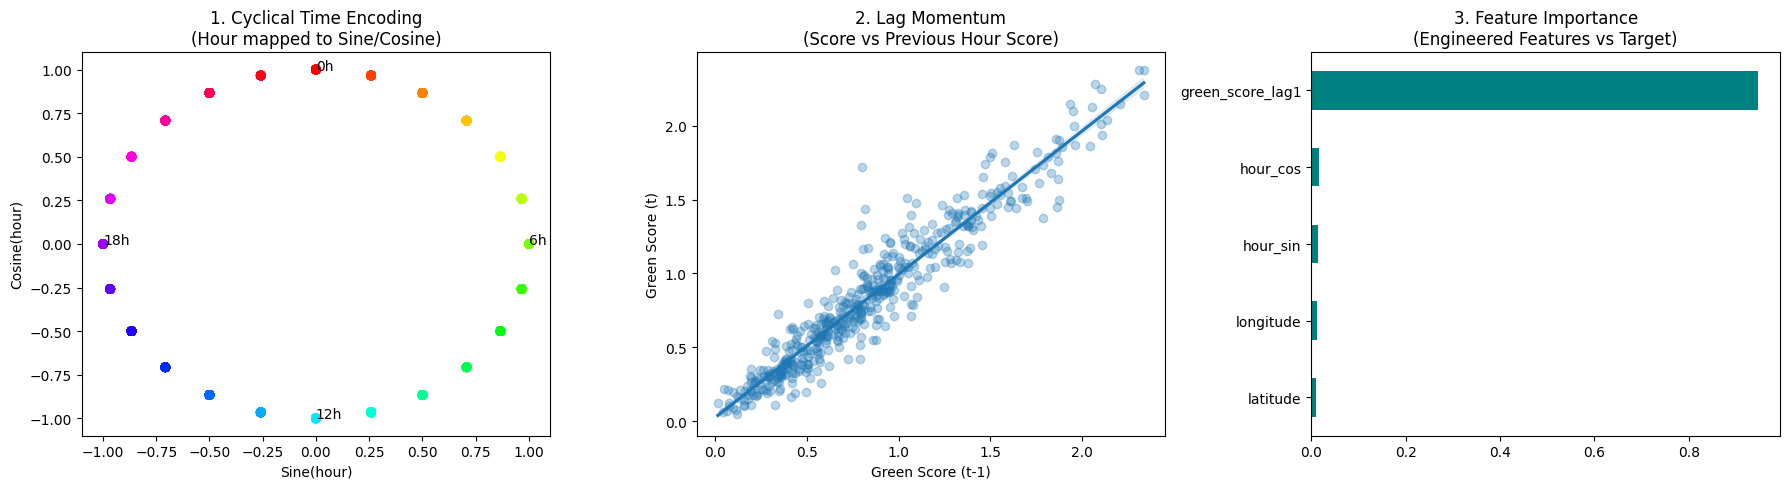

In [3]:
# FEATURE ENGINEERING (Deriving New Values)
# To forecast the future, the model needs to understand two things: Cycles (day vs. night) and Momentum (what happened an hour ago).
# 1. Cyclical Encoding: Hours are circular (23:00 is close to 00:00). We use Sine and Cosine to represent this.
# 2. Lags: We give the model the values from 1, 2, and 3 hours ago.
# 3. Rolling Averages: We provide the average wind/solar for the last 3 hours to show the "trend."

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Engineering
df['hour'] = df['time'].dt.hour
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
for col in ['green_score', 'wind_speed_100m', 'shortwave_radiation']:
    df[f'{col}_lag1'] = df.groupby('city')[col].shift(1)
    df[f'{col}_lag2'] = df.groupby('city')[col].shift(2)
df_clean = df.dropna()

# Multi-Plot figure to show "Feature Engineering"
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Cyclical Time Encoding
ax[0].scatter(df['hour_sin'], df['hour_cos'], c=df['hour'], cmap='hsv', alpha=0.5)
ax[0].set_title('1. Cyclical Time Encoding\n(Hour mapped to Sine/Cosine)')
ax[0].set_xlabel('Sine(hour)')
ax[0].set_ylabel('Cosine(hour)')
for i in [0, 6, 12, 18]:
    ax[0].annotate(f'{i}h', (np.sin(2*np.pi*i/24), np.cos(2*np.pi*i/24)))

# Plot 2: Lag Correlation
sns.regplot(x='green_score_lag1', y='green_score', data=df_clean.sample(500), ax=ax[1], scatter_kws={'alpha':0.3})
ax[1].set_title('2. Lag Momentum\n(Score vs Previous Hour Score)')
ax[1].set_xlabel('Green Score (t-1)')
ax[1].set_ylabel('Green Score (t)')

# Plot 3: Feature Importance
# Re-running a quick model to get importances for this specific visual
features = ['hour_sin', 'hour_cos', 'green_score_lag1', 'latitude', 'longitude']
model = RandomForestRegressor(n_estimators=50, random_state=42)
model.fit(df_clean[features], df_clean['green_score'])
importances = pd.Series(model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=ax[2], color='teal')
ax[2].set_title('3. Feature Importance\n(Engineered Features vs Target)')

plt.tight_layout()

In [4]:
# SPLITTING THE DATA (The "Time-Series" Way)
# Never shuffle time-series data. You must train on the "past" and test on the "future."

# We will take the last 24 hours of each city as our 'Test' set 
# and everything before that as our 'Train' set.
test_cutoff = df['time'].max() - pd.Timedelta(hours=24)

train = df[df['time'] <= test_cutoff]
test = df[df['time'] > test_cutoff]

# Define which columns the model should look at (Features) 
# and what it is trying to predict (Target)
features = ['hour_sin', 'hour_cos', 'latitude', 'longitude', 
            'green_score_lag1', 'green_score_lag2', 
            'wind_speed_100m_lag1', 'shortwave_radiation_lag1']

X_train, y_train = train[features], train['green_score']
X_test, y_test = test[features], test['green_score']

In [5]:
# MODEL TRAINING (XGBoost)
# We use XGBoost because it is a "Gradient Boosting" model. 
# It builds many small decision trees, each one learning from the mistakes of the previous one. 
# It is excellent for capturing the non-linear relationship of solar/wind.

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=5)

# Train (Fit) the model
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

# Evaluate the accuracy
print(f"R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Mean Error: {mean_absolute_error(y_test, predictions):.4f}")

R2 Score: 0.9357
Mean Error: 0.0861


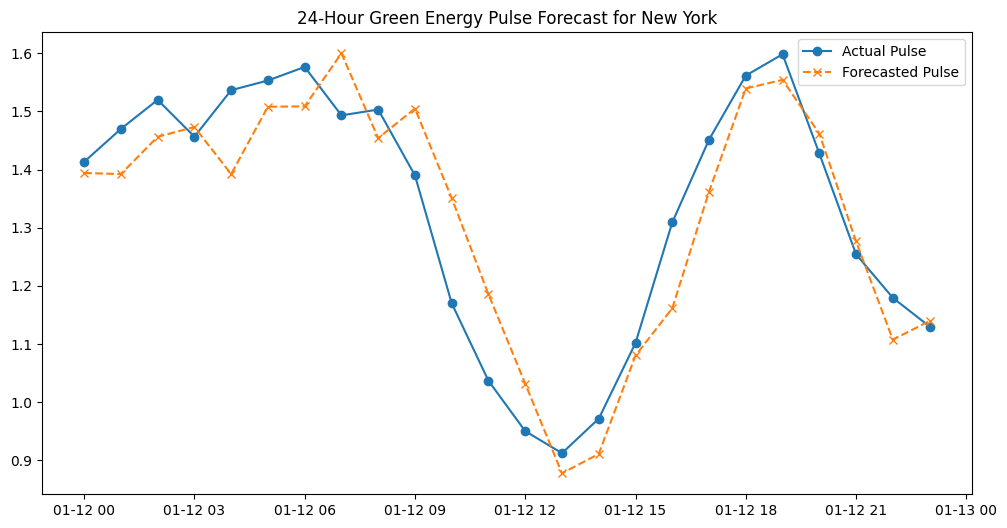

In [6]:
# UNDERSTANDING THE SYSTEM (Forecast vs. Reality)

# Pick one city to visualize (e.g., New York, Beijing, Tokyo, Sao Paulo, Mumbai, London, Sydney, Berlin, Cairo & Lagos)
city_name = "New York"
city_test = test[test['city'] == city_name]
city_preds = model.predict(city_test[features])

plt.figure(figsize=(12,6))
plt.plot(city_test['time'], city_test['green_score'], label='Actual Pulse', marker='o')
plt.plot(city_test['time'], city_preds, label='Forecasted Pulse', linestyle='--', marker='x')
plt.title(f"24-Hour Green Energy Pulse Forecast for {city_name}")
plt.legend()
plt.show()